# Neuronales Netz

## 1. Setup

- **Algorithmus:** Sequential mit Dense-Layern (TensorFlow/Keras)
- **Regularisierung:** Dropout, Early Stopping
- **Split:** 70/15/15 (Train / Validation / Test)

In [1]:
import json
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# Projektkonfiguration
# ============================================================
PROJECT_ROOT = Path("../")

DATA_DIR   = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_70_15_15.jsonl"
VAL_FILE   = DATA_DIR / "val_0_50000_70_15_15.jsonl"
TEST_FILE  = DATA_DIR / "test_0_50000_70_15_15.jsonl"

CLASS_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

# Datenmenge pro Kategorie aus Split-Dateinamen ableiten
train_n = int(TRAIN_FILE.stem.split("_")[2])
test_n = int(TEST_FILE.stem.split("_")[2])
assert train_n == test_n, f"Unterschiedliche Datenmengen: Train={train_n}, Test={test_n}"
SAMPLES_PER_CAT = train_n
SAMPLE_SUFFIX = f"{SAMPLES_PER_CAT // 1000}k" if SAMPLES_PER_CAT >= 1000 else str(SAMPLES_PER_CAT)

print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"VAL_FILE   existiert: {VAL_FILE.exists()}")
print(f"TEST_FILE  existiert: {TEST_FILE.exists()}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Datenmenge pro Kategorie: {SAMPLES_PER_CAT:,} ({SAMPLE_SUFFIX})")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
VAL_FILE   existiert: True
TEST_FILE  existiert: True
TensorFlow Version: 2.20.0
Datenmenge pro Kategorie: 50,000 (50k)


## 2. Hyperparameter
| Parameter | Beschreibung | Typische Werte |
|---|---|---|
| `HIDDEN_UNITS` | Neuronen je Hidden Layer | 64 – 512 |
| `DROPOUT_RATE` | Dropout-Rate zur Regularisierung | 0.0 – 0.5 |
| `LEARNING_RATE` | Lernrate des Optimierers | 0.0001 – 0.01 |
| `BATCH_SIZE` | Batch-Größe beim Training | 32 – 256 |
| `EPOCHS` | Max. Trainingsepochen | 10 – 50 |
| `MAX_FEATURES` | Max. Anzahl TF-IDF-Features | 1.000 – 100.000 |
| `MIN_DF` | Min. Dokumenthäufigkeit eines Terms | 1 – 10 |
| `MAX_DF` | Max. Dokumenthäufigkeit eines Terms | 0.7 – 1.0 |
| `NGRAM_RANGE` | Uni- und/oder Bigramme | (1,1), (1,2) |
| `STOP_WORDS` | Stoppwörter entfernen | 'english', None |
| `SUBLINEAR_TF` | Logarithmische TF-Skalierung | True, False |

In [2]:
# ============================================================
# HYPERPARAMETER – hier anpassen!
# ============================================================

# Netzarchitektur
HIDDEN_UNITS  = 256     # Neuronen je Hidden Layer
DROPOUT_RATE  = 0.3     # Dropout-Rate zur Regularisierung
LEARNING_RATE = 0.001   # Lernrate des Adam-Optimierers

# Training
BATCH_SIZE = 128        # Batch-Größe
EPOCHS     = 20         # Max. Trainingsepochen (Early Stopping greift ggf. früher)

# TF-IDF Vektorizer
MAX_FEATURES = 10000    # Anzahl der Features (Vokabular-Größe)
MIN_DF       = 2        # Term muss in mind. N Dokumenten vorkommen
MAX_DF       = 0.95     # Term darf in höchstens X% der Dokumente vorkommen
NGRAM_RANGE  = (1, 2)   # (1,1) = Unigramme; (1,2) = Uni- + Bigramme
STOP_WORDS   = 'english'  # Stoppwörter: 'english' oder None
SUBLINEAR_TF = False    # True = log(TF) statt TF; oft besser bei langen Texten

print("Aktuelle Hyperparameter:")
print(f"  HIDDEN_UNITS  = {HIDDEN_UNITS}")
print(f"  DROPOUT_RATE  = {DROPOUT_RATE}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  EPOCHS        = {EPOCHS}")
print(f"  MAX_FEATURES  = {MAX_FEATURES}")
print(f"  MIN_DF        = {MIN_DF}")
print(f"  MAX_DF        = {MAX_DF}")
print(f"  NGRAM_RANGE   = {NGRAM_RANGE}")
print(f"  STOP_WORDS    = {STOP_WORDS}")
print(f"  SUBLINEAR_TF  = {SUBLINEAR_TF}")

Aktuelle Hyperparameter:
  HIDDEN_UNITS  = 256
  DROPOUT_RATE  = 0.3
  LEARNING_RATE = 0.001
  BATCH_SIZE    = 128
  EPOCHS        = 20
  MAX_FEATURES  = 10000
  MIN_DF        = 2
  MAX_DF        = 0.95
  NGRAM_RANGE   = (1, 2)
  STOP_WORDS    = english
  SUBLINEAR_TF  = False


## 3. Trainingsdaten laden

In [3]:
def load_data(filepath):
    """Lädt JSONL-Datei und kombiniert title + text."""
    texts, ratings = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            texts.append(f"{data['title']} {data['text']}")
            ratings.append(int(data['rating']))
    return texts, ratings

print("Lade Trainingsdaten ...")
X_train_texts, y_train_raw = load_data(TRAIN_FILE)
print(f"  Train:      {len(X_train_texts):>7,} Samples")

print("Lade Validierungsdaten ...")
X_val_texts, y_val_raw = load_data(VAL_FILE)
print(f"  Validation: {len(X_val_texts):>7,} Samples")

print("Lade Testdaten ...")
X_test_texts, y_test_raw = load_data(TEST_FILE)
print(f"  Test:       {len(X_test_texts):>7,} Samples")

Lade Trainingsdaten ...
  Train:      140,000 Samples
Lade Validierungsdaten ...
  Validation:  30,000 Samples
Lade Testdaten ...
  Test:        30,000 Samples


## 4. Klassenverteilung prüfen

In [4]:
# Class Distribution
train_dist = pd.Series(y_train_raw).value_counts().sort_index()
test_dist = pd.Series(y_test_raw).value_counts().sort_index()

print("\nTraining Set Distribution:")
print(train_dist)
print(f"\nTest Set Distribution:")
print(test_dist)


Training Set Distribution:
1     8527
2     6005
3    11888
4    23537
5    90043
Name: count, dtype: int64

Test Set Distribution:
1     1961
2     1210
3     2291
4     4671
5    19867
Name: count, dtype: int64


## 5. TF-IDF Vektorisierung

In [5]:
print("Vektorisierung (TF-IDF) ...")
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    lowercase=True,
    stop_words=STOP_WORDS,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=SUBLINEAR_TF
)

X_train = vectorizer.fit_transform(X_train_texts).toarray()
X_val   = vectorizer.transform(X_val_texts).toarray()
X_test  = vectorizer.transform(X_test_texts).toarray()

# Labels: 1-5 -> 0-4
y_train = np.array(y_train_raw) - 1
y_val   = np.array(y_val_raw) - 1
y_test  = np.array(y_test_raw) - 1

print(f"✓ Feature-Dimension: {X_train.shape[1]:,}")
print(f"✓ Train-Matrix:      {X_train.shape}")
print(f"✓ Val-Matrix:        {X_val.shape}")
print(f"✓ Test-Matrix:       {X_test.shape}")

Vektorisierung (TF-IDF) ...
✓ Feature-Dimension: 10,000
✓ Train-Matrix:      (140000, 10000)
✓ Val-Matrix:        (30000, 10000)
✓ Test-Matrix:       (30000, 10000)


## 6. Training

In [6]:
# Modell definieren
model = keras.Sequential([
    layers.Input(shape=(MAX_FEATURES,)),
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

print("\nTrainiere neuronales Netz ...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)
print("✓ Training abgeschlossen")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627,333 (10.02 MB)

 Trainable params: 2,627,333 (10.02 MB)

 Non-trainable params: 0 (0.00 B)


Trainiere neuronales Netz ...
Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.7024 - loss: 0.7836 - val_accuracy: 0.7224 - val_loss: 0.7276
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.7482 - loss: 0.6595 - val_accuracy: 0.7175 - val_loss: 0.7421
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7902 - loss: 0.5627 - val_accuracy: 0.7132 - val_loss: 0.7904
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8417 - loss: 0.4344 - val_accuracy: 0.7044 - val_loss: 0.8958
✓ Training abgeschlossen


## 7. Evaluierung

In [9]:
y_pred = np.argmax(model.predict(X_test), axis=1)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Macro-Metriken berechnen
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro'
)

print(f"{'='*60}")
print(f"TEST-EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
TEST-EVALUIERUNG
Accuracy: 0.7324

Confusion Matrix:
[[ 1282    79   182    22   396]
 [  332    98   339    50   391]
 [  186    79   752   273  1001]
 [   62    15   328   721  3545]
 [   89    10   228   422 19118]]

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.66      0.65      0.66      1961
     2 Stars       0.35      0.08      0.13      1210
     3 Stars       0.41      0.33      0.37      2291
     4 Stars       0.48      0.15      0.23      4671
     5 Stars       0.78      0.96      0.86     19867

    accuracy                           0.73     30000
   macro avg       0.54      0.44      0.45     30000
weighted avg       0.68      0.73      0.68     30000



## 8. Ergebnisse speichern

Run-Verzeichnis: ..\results\neural\runs\run_01_50k


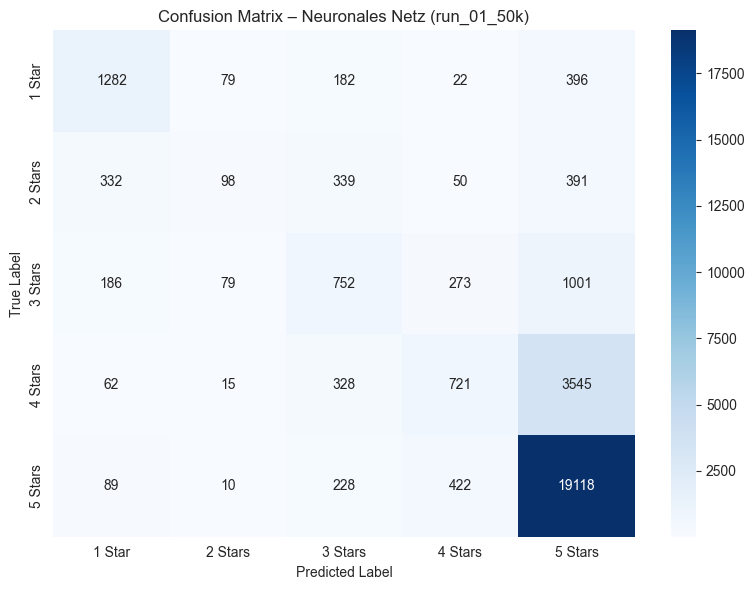

✓ Metriken, Modell und Confusion Matrix in ..\results\neural\runs\run_01_50k
✓ Overview aktualisiert: ..\results\neural\runs\overview.csv


In [10]:
# ============================================================
# Run-Verzeichnis ermitteln
# ============================================================
RUNS_DIR = PROJECT_ROOT / "results" / "neural" / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

existing_runs = [d.name for d in RUNS_DIR.iterdir() if d.is_dir() and d.name.startswith("run_")]
if existing_runs:
    max_num = max(int(name.split("_")[1]) for name in existing_runs)
    run_num = max_num + 1
else:
    run_num = 1

run_name = f"run_{run_num:02d}_{SAMPLE_SUFFIX}"
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run-Verzeichnis: {RUN_DIR}")

# ============================================================
# Metriken speichern
# ============================================================
epochs_trained = len(history.history['loss'])

results = {
    'run': run_name,
    'accuracy': float(accuracy),
    'precision_macro': float(precision_macro),
    'recall_macro': float(recall_macro),
    'f1_macro': float(f1_macro),
    'num_train_samples': len(y_train),
    'num_val_samples': len(y_val),
    'num_test_samples': len(y_test),
    'train_file': TRAIN_FILE.name,
    'val_file': VAL_FILE.name,
    'test_file': TEST_FILE.name,
    'classes': CLASS_NAMES,
    'hyperparameters': {
        'hidden_units': HIDDEN_UNITS,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': epochs_trained,
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': list(NGRAM_RANGE),
        'stop_words': STOP_WORDS,
        'sublinear_tf': SUBLINEAR_TF
    }
}
with open(RUN_DIR / "metrics.json", 'w') as f:
    json.dump(results, f, indent=2)

# Modell + Vectorizer
model.save(RUN_DIR / 'model.keras')
with open(RUN_DIR / "vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix – Neuronales Netz ({run_name})')
plt.tight_layout()
plt.savefig(RUN_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Overview-CSV aktualisieren
hyperparams_str = (
    f"hidden_units: {HIDDEN_UNITS} | dropout_rate: {DROPOUT_RATE} | "
    f"learning_rate: {LEARNING_RATE} | batch_size: {BATCH_SIZE} | "
    f"epochs_trained: {epochs_trained} | max_features: {MAX_FEATURES} | "
    f"min_df: {MIN_DF} | max_df: {MAX_DF} | ngram_range: {NGRAM_RANGE} | "
    f"stop_words: {STOP_WORDS} | sublinear_tf: {SUBLINEAR_TF}"
)
row = pd.DataFrame({
    'Run':             [run_name],
    'Accuracy':        [accuracy],
    'Precision_Macro': [precision_macro],
    'Recall_Macro':    [recall_macro],
    'F1_Macro':        [f1_macro],
    'Train_Samples':   [len(y_train)],
    'Test_Samples':    [len(y_test)],
    'Hyperparameters': [hyperparams_str]
})

overview_path = RUNS_DIR / "overview.csv"
if overview_path.exists():
    existing = pd.read_csv(overview_path, sep=';')
    overview = pd.concat([existing, row], ignore_index=True)
else:
    overview = row
overview.to_csv(overview_path, index=False, sep=';')

print(f"✓ Metriken, Modell und Confusion Matrix in {RUN_DIR}")
print(f"✓ Overview aktualisiert: {overview_path}")

### Confusion Matrix – Interpretation

**Struktur:**
- Zeilen = True Label (tatsächliche Klasse)
- Spalten = Predicted Label (vom Modell vorhergesagte Klasse)

**Für jede Klasse (Beispiel: "5 Stars"):**

**TP (True Positives) – Diagonale:** Korrekt als diese Klasse vorhergesagt.

**FP (False Positives) – Spalte (ohne Diagonale):** Fälschlicherweise als diese Klasse klassifiziert.

**FN (False Negatives) – Zeile (ohne Diagonale):** Gehört zu dieser Klasse, wurde aber falsch klassifiziert.

**TN (True Negatives):** Alles außerhalb der Zeile und Spalte dieser Klasse.